In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 1. Carregar o dataset clássico da UCI
raw_data = load_breast_cancer()
X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
y = raw_data.target

# 2. Dividir o conjunto de dados
# Para treino em 2/3 e para teste em 1/3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

print(f"Dataset carregado! Total de atributos: {X.shape[1]}")
print(f"Classes: {raw_data.target_names} (0 = Maligno, 1 = Benigno)")

Dataset carregado! Total de atributos: 30
Classes: ['malignant' 'benign'] (0 = Maligno, 1 = Benigno)


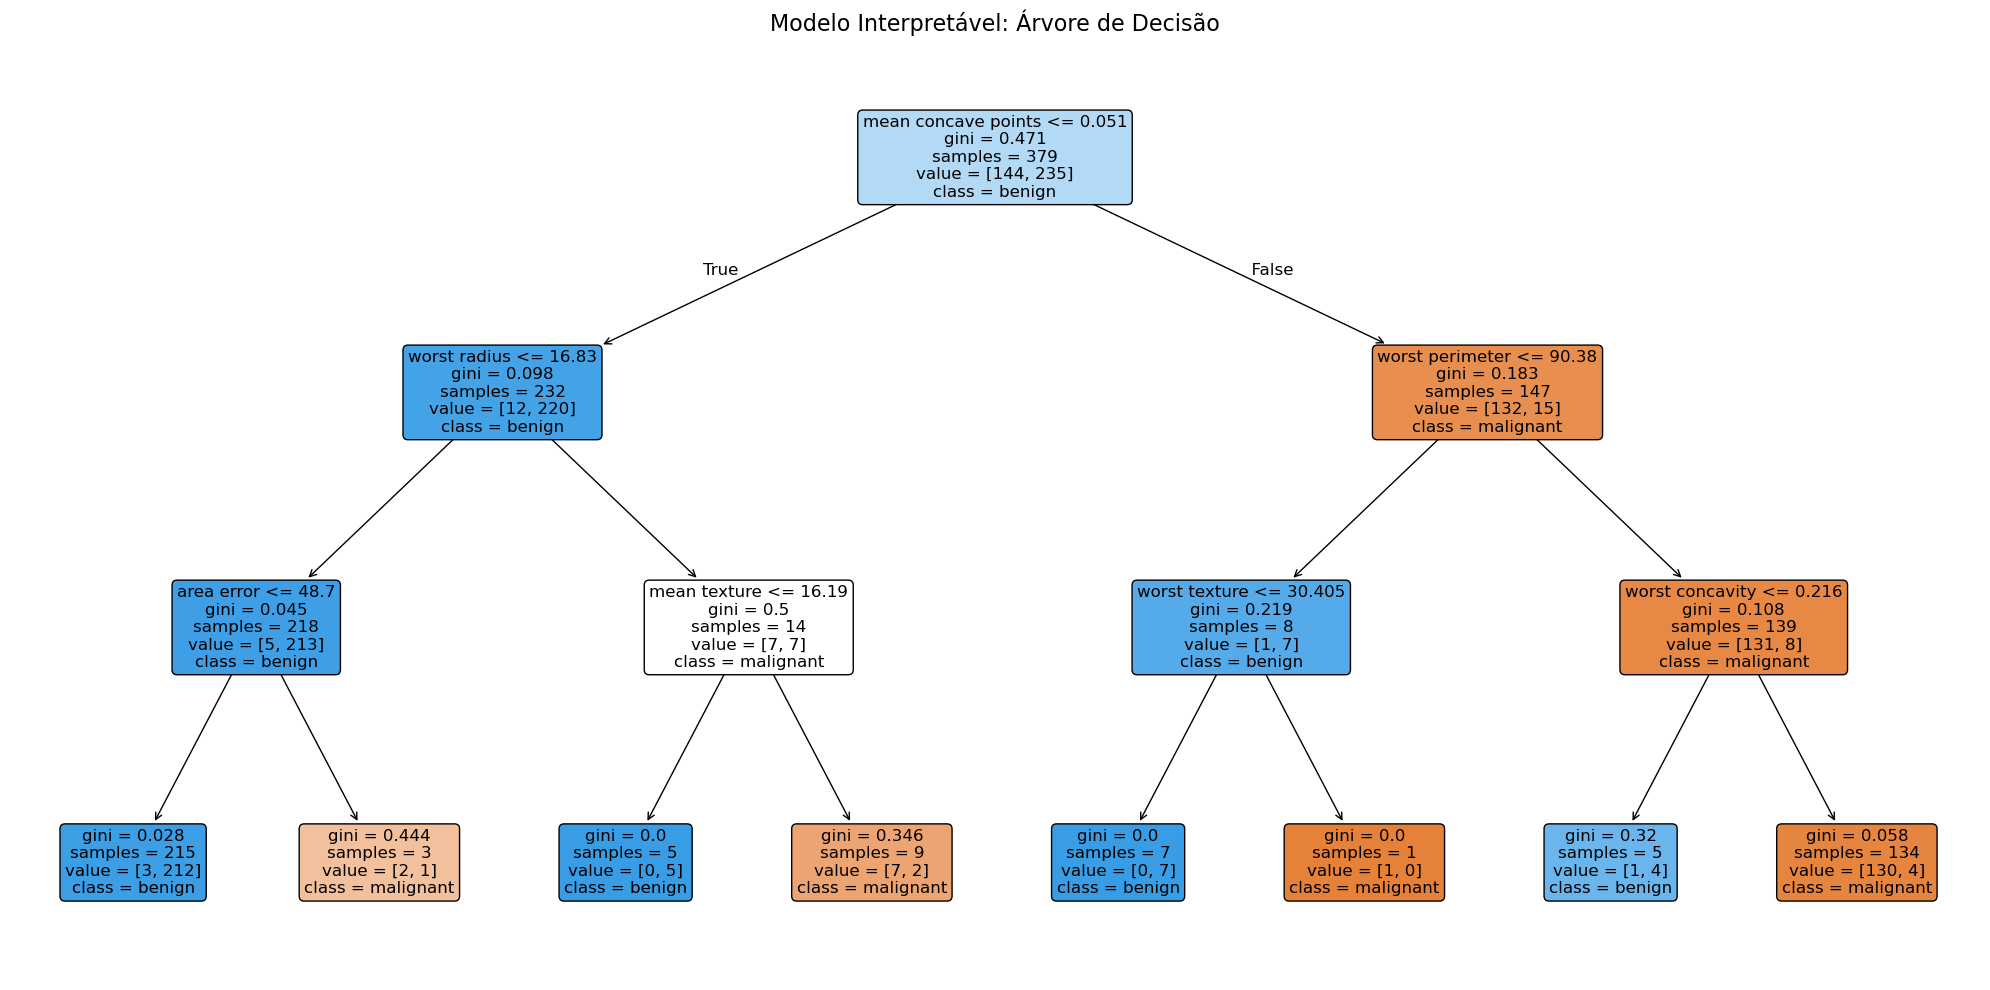

Acurácia da Árvore no teste: 0.9579


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Treinar uma árvore de decisão simples
decision_tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
decision_tree_model.fit(X_train, y_train)

# Plotar a estrutura interna do modelo
plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree_model, 
    feature_names=raw_data.feature_names, 
    class_names=raw_data.target_names, 
    filled=True, 
    rounded=True,
    fontsize=12
)
plt.title("Modelo Interpretável: Árvore de Decisão", fontsize=16)
plt.tight_layout()
plt.savefig("decision-tree-model.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Acurácia da Árvore no teste: {decision_tree_model.score(X_test, y_test):.4f}")

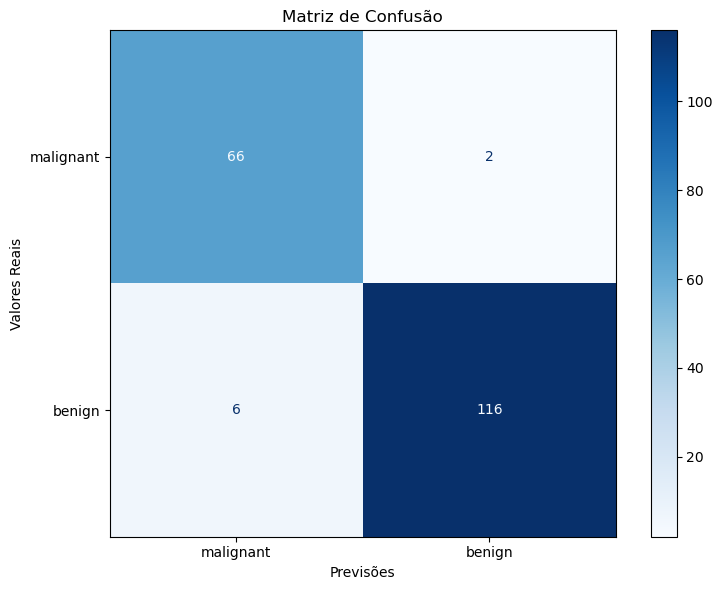

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Fazer as previsões com o modelo treinado
prediction = decision_tree_model.predict(X_test)

# 2. Criar a matriz de confusão
cm = confusion_matrix(y_test, prediction)

# 3. Configurar a visualização
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=raw_data.target_names)

# 4. Desenhar o gráfico
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.title("Matriz de Confusão")
plt.xlabel("Previsões")
plt.ylabel("Valores Reais")
plt.tight_layout()
plt.savefig("decision-tree-confusion-matrix.png", dpi=300, bbox_inches='tight')
plt.show()